# 🎬 Movie Genre Classifier — LSTM with PyTorch
> **Goal:** Predict a movie's genre from its overview/description using a Bidirectional LSTM model.

---
| Step | Description |
|------|-------------|
| 1 | Setup & Imports |
| 2 | Data Loading & Exploration |
| 3 | Preprocessing & Vocabulary |
| 4 | Dataset & DataLoaders |
| 5 | Model Architecture (BiLSTM) |
| 6 | Training Loop |
| 7 | Evaluation & Metrics |
| 8 | Predict Any Movie Description |

---
## 📦 Step 1 — Setup & Imports

In [1]:
import random
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
print(f'✅ PyTorch version: {torch.__version__}')

✅ Using device: cpu
✅ PyTorch version: 2.11.0+cpu


---
## 📂 Step 2 — Data Loading & Exploration

In [2]:
# ── Load Data ─────────────────────────────────────────────────────
df = pd.read_csv('movies_dataset.csv', encoding='utf-8-sig')
print(f'📊 Dataset shape: {df.shape}')
df[['title', 'genres', 'overview']].head(5)

📊 Dataset shape: (6000, 10)


,title,genres,overview
0,Four Rooms,Comedy,It's Ted the Bellhop's first night on the job....
1,Star Wars,"Adventure, Action, Science Fiction",Princess Leia is captured and held hostage by ...
2,Finding Nemo,"Animation, Family, Adventure","Nemo, an adventurous young clownfish, is unexp..."
3,Forrest Gump,"Comedy, Drama, Romance",A man with a low IQ has accomplished great thi...
4,American Beauty,Drama,"Lester Burnham, a depressed suburban father in..."


C:\Users\SOFT LAPTOP\AppData\Local\Temp\ipykernel_7944\3846390482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Genre', y='Count', palette='viridis')


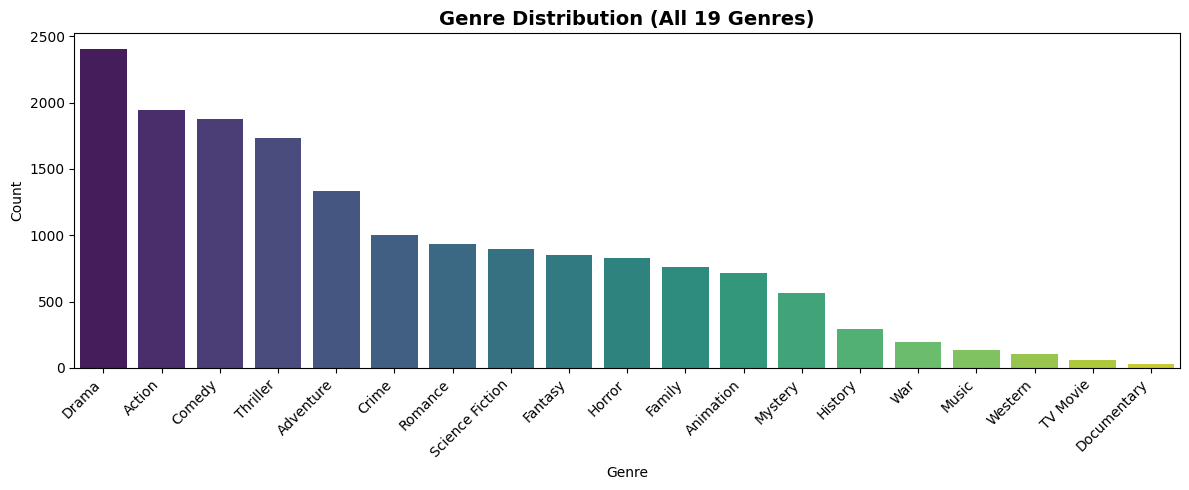

          Genre  Count
          Drama   2402
         Action   1941
         Comedy   1873
       Thriller   1732
      Adventure   1332
          Crime   1003
        Romance    935
Science Fiction    896
        Fantasy    850
         Horror    829
         Family    759
      Animation    715
        Mystery    561
        History    292
            War    193
          Music    138
        Western    108
       TV Movie     56
    Documentary     31


In [3]:
# ── Genre Distribution ─────────────────────────────────────────────
all_genres = []
for g in df['genres'].dropna():
    for genre in str(g).split(','):
        all_genres.append(genre.strip())

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(19), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=genre_df, x='Genre', y='Count', palette='viridis')
plt.title('Genre Distribution (All 19 Genres)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(genre_df.to_string(index=False))

---
## ⚙️ Step 3 — Preprocessing & Vocabulary

> We keep only the **Top 8 most frequent genres** to maximise accuracy and reduce label noise.

In [4]:
# ── Top-8 Genres ─────────────────────────────────────────────────
TOP_N = 8
TOP_GENRES = [g for g, _ in genre_counts.most_common(TOP_N)]
print('🎯 Top 8 genres selected:')
for i, g in enumerate(TOP_GENRES, 1):
    print(f'   {i}. {g}')

# ── Assign primary genre (first matching top-8 genre per movie) ───
def get_primary_genre(genres_str):
    """Return the first genre that belongs to TOP_GENRES list."""
    for g in str(genres_str).split(','):
        g = g.strip()
        if g in TOP_GENRES:
            return g
    return None

df['primary_genre'] = df['genres'].apply(get_primary_genre)
df_clean = df[df['primary_genre'].notna() & df['overview'].notna()].copy()
df_clean = df_clean[df_clean['overview'].str.strip().str.len() > 20]

print(f'\n✅ Movies after filtering: {len(df_clean)}')
print('\n📊 Samples per genre:')
print(df_clean['primary_genre'].value_counts())

🎯 Top 8 genres selected:
   1. Drama
   2. Action
   3. Comedy
   4. Thriller
   5. Adventure
   6. Crime
   7. Romance
   8. Science Fiction

✅ Movies after filtering: 5716

📊 Samples per genre:
primary_genre
Action             1295
Drama              1279
Comedy             1123
Adventure           611
Thriller            553
Science Fiction     345
Crime               289
Romance             221
Name: count, dtype: int64


In [5]:
# ── Label Encoding ───────────────────────────────────────────────
GENRES_LIST = sorted(df_clean['primary_genre'].unique().tolist())
genre2idx   = {g: i for i, g in enumerate(GENRES_LIST)}
idx2genre   = {i: g for g, i in genre2idx.items()}
NUM_CLASSES = len(GENRES_LIST)

df_clean['label'] = df_clean['primary_genre'].map(genre2idx)
print(f'Number of classes: {NUM_CLASSES}')
print('Mapping:', genre2idx)

Number of classes: 8
Mapping: {'Action': 0, 'Adventure': 1, 'Comedy': 2, 'Crime': 3, 'Drama': 4, 'Romance': 5, 'Science Fiction': 6, 'Thriller': 7}


In [6]:
# ── Text Cleaning ────────────────────────────────────────────────
STOPWORDS = {
    'a','an','the','is','it','in','on','at','to','of','and','or','but',
    'for','with','this','that','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','shall','should',
    'may','might','must','can','could','not','no','nor','so','yet','both',
    'either','neither','each','few','more','most','other','some','such',
    'than','too','very','just','as','by','from','up','about','into',
    'through','during','before','after','above','below','between','out',
    'off','over','under','again','then','once','here','there','when',
    'where','why','how','all','both','he','she','they','we','you','i',
    'me','him','her','them','us','its','his','my','your','our','their',
    'what','which','who','whom','whose'
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s']", ' ', text)        # keep letters & apostrophes
    text = re.sub(r"\s+", ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return tokens

df_clean['tokens'] = df_clean['overview'].apply(clean_text)

# Preview
sample = df_clean[['title','primary_genre','tokens']].iloc[0]
print(f'Title  : {sample["title"]}')
print(f'Genre  : {sample["primary_genre"]}')
print(f'Tokens : {sample["tokens"][:15]} ...')

Title  : Four Rooms
Genre  : Comedy
Tokens : ["it's", 'ted', "bellhop's", 'first', 'night', 'job', "hotel's", 'unusual', 'guests', 'place', 'outrageous', 'predicaments', 'seems', "evening's", 'room'] ...


In [7]:
# ── Build Vocabulary ─────────────────────────────────────────────
MIN_FREQ = 2

token_freq = Counter(t for tokens in df_clean['tokens'] for t in tokens)
vocab_tokens = [t for t, c in token_freq.items() if c >= MIN_FREQ]

# Special tokens
PAD_TOKEN = '<PAD>'   # index 0
UNK_TOKEN = '<UNK>'   # index 1

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for t in sorted(vocab_tokens):
    word2idx[t] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'📖 Vocabulary size : {VOCAB_SIZE:,}')
print(f'📝 Total tokens    : {sum(token_freq.values()):,}')

📖 Vocabulary size : 11,781
📝 Total tokens    : 155,338


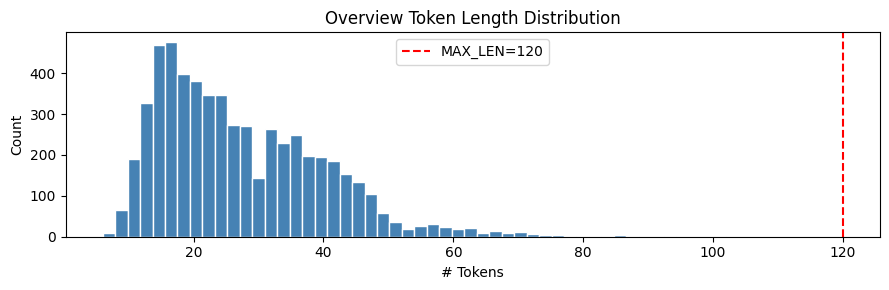

Coverage at MAX_LEN=120: 100.0%


In [8]:
# ── Numericalize & Pad ────────────────────────────────────────────
MAX_LEN = 120   # description length cap (covers ~95% of samples)

def encode(tokens):
    ids = [word2idx.get(t, 1) for t in tokens[:MAX_LEN]]
    # Pad / truncate to MAX_LEN
    ids += [0] * (MAX_LEN - len(ids))
    return ids

df_clean['encoded'] = df_clean['tokens'].apply(encode)

# Quick length histogram
lengths = df_clean['tokens'].apply(len)
plt.figure(figsize=(9, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Overview Token Length Distribution')
plt.xlabel('# Tokens'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Coverage at MAX_LEN={MAX_LEN}: {(lengths <= MAX_LEN).mean()*100:.1f}%')

---
## 🗂️ Step 4 — Dataset & DataLoaders

In [9]:
# ── Train / Val / Test Split ─────────────────────────────────────
X = np.array(df_clean['encoded'].tolist(), dtype=np.int64)
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f'Train : {len(X_train):>5,} samples')
print(f'Val   : {len(X_val):>5,} samples')
print(f'Test  : {len(X_test):>5,} samples')

Train : 4,129 samples
Val   :   729 samples
Test  :   858 samples


In [10]:
# ── PyTorch Dataset ───────────────────────────────────────────────
class MovieDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── DataLoaders ──────────────────────────────────────────────────
BATCH_SIZE = 64

train_loader = DataLoader(MovieDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(MovieDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(MovieDataset(X_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print('✅ DataLoaders ready.')
print(f'   Batches per epoch (train): {len(train_loader)}')

✅ DataLoaders ready.
   Batches per epoch (train): 64


---
## 🧠 Step 5 — Model Architecture (Bidirectional LSTM)

In [11]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM with:
      • Embedding layer (trainable)
      • 2-layer BiLSTM
      • Attention pooling over hidden states
      • Fully-connected head with dropout + BatchNorm
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout=0.4, pad_idx=0):
        super().__init__()

        # ── Embedding ───────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=pad_idx)

        # ── BiLSTM ──────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0.0
        )

        # ── Attention ───────────────────────────────────────────
        self.attention = nn.Linear(hidden_dim * 2, 1)

        # ── Classifier head ─────────────────────────────────────
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        for name, p in self.lstm.named_parameters():
            if 'weight' in name:  nn.init.orthogonal_(p)
            if 'bias'   in name:  nn.init.zeros_(p)

    def attention_pool(self, lstm_out):
        """Soft-attention over all time-steps."""
        scores  = self.attention(lstm_out).squeeze(-1)   # (B, T)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        context = (weights * lstm_out).sum(dim=1)             # (B, 2H)
        return context

    def forward(self, x):
        emb      = self.embedding(x)             # (B, T, E)
        out, _   = self.lstm(emb)                # (B, T, 2H)
        context  = self.attention_pool(out)      # (B, 2H)
        logits   = self.fc(context)              # (B, C)
        return logits


# ── Hyper-parameters ─────────────────────────────────────────────
EMBED_DIM  = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.4

model = BiLSTMClassifier(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n🔢 Trainable parameters: {total_params:,}')

BiLSTMClassifier(
  (embedding): Embedding(11781, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=8, bias=True)
  )
)

🔢 Trainable parameters: 4,041,737


---
## 🏋️ Step 6 — Training Loop

In [12]:
# ── Class weights to handle imbalance ────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# ── Loss / Optimiser / Scheduler ─────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

print('✅ Loss / Optimizer / Scheduler configured.')

✅ Loss / Optimizer / Scheduler configured.


In [13]:
# ── Training Utilities ────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total

print('✅ Utilities defined.')

✅ Utilities defined.


In [ ]:
# ── Main Training Loop ────────────────────────────────────────────
EPOCHS      = 30
PATIENCE    = 6          # early stopping patience
BEST_PATH   = 'best_model.pt'

history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

best_val_acc  = 0.0
no_improve    = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # ── Save best ───────────────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), BEST_PATH)
        tag = '  ⭐ saved'
        no_improve = 0
    else:
        tag = ''
        no_improve += 1

    print(f'Epoch {epoch:02d}/{EPOCHS} │ '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% │ '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%'
          + tag)

    if no_improve >= PATIENCE:
        print(f'\n🛑 Early stopping triggered after {epoch} epochs.')
        break

print(f'\n🏆 Best Validation Accuracy: {best_val_acc*100:.2f}%')

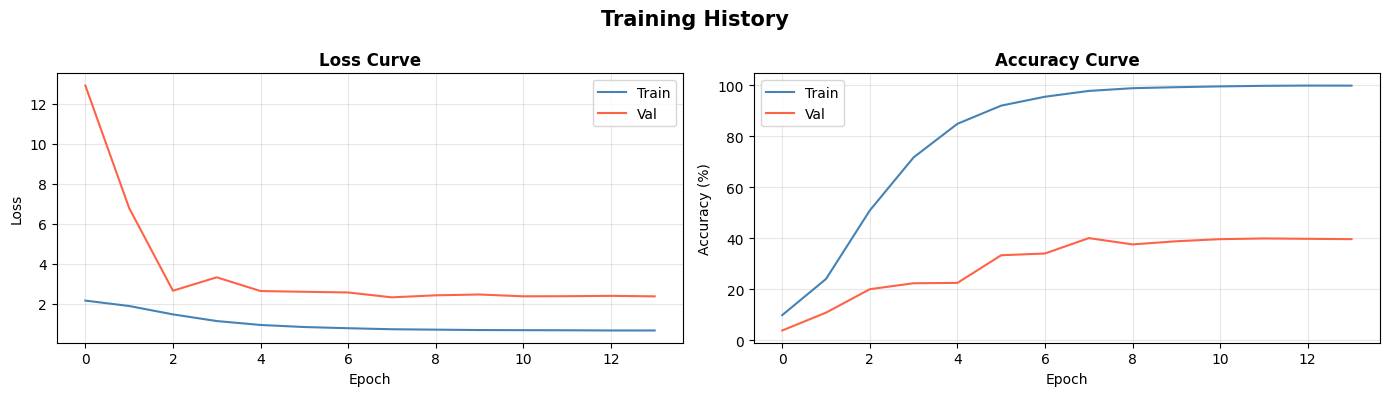

In [ ]:
# ── Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 📊 Step 7 — Evaluation & Metrics

In [ ]:
# ── Load best weights & evaluate on TEST set ─────────────────────
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'🎯 Test Accuracy : {test_acc*100:.2f}%')
print(f'   Test Loss     : {test_loss:.4f}')

🎯 Test Accuracy : 38.93%
   Test Loss     : 2.3820


In [ ]:
# ── Full Classification Report ────────────────────────────────────
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        logits = model(X_batch.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(y_batch.tolist())
    return all_labels, all_preds

y_true, y_pred = get_preds(model, test_loader)

print('\n📋 Classification Report:\n')
print(classification_report(
    y_true, y_pred,
    target_names=[idx2genre[i] for i in range(NUM_CLASSES)]
))


📋 Classification Report:

                 precision    recall  f1-score   support

         Action       0.51      0.41      0.45       194
      Adventure       0.39      0.38      0.39        92
         Comedy       0.41      0.36      0.38       169
          Crime       0.20      0.21      0.21        43
          Drama       0.38      0.58      0.46       192
        Romance       0.33      0.03      0.06        33
Science Fiction       0.27      0.38      0.32        52
       Thriller       0.35      0.22      0.27        83

       accuracy                           0.39       858
      macro avg       0.36      0.32      0.32       858
   weighted avg       0.40      0.39      0.38       858



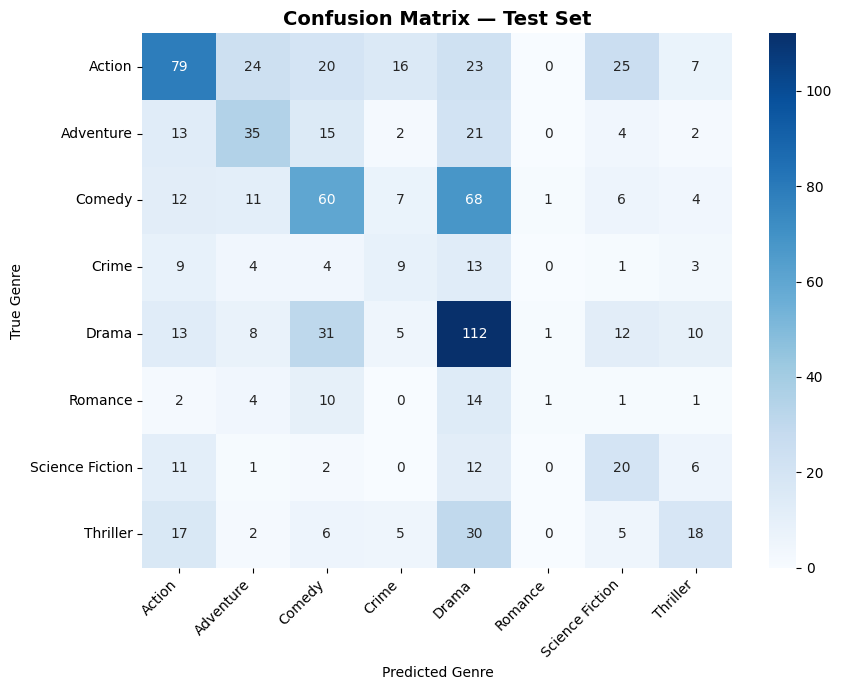

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
labels = [idx2genre[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

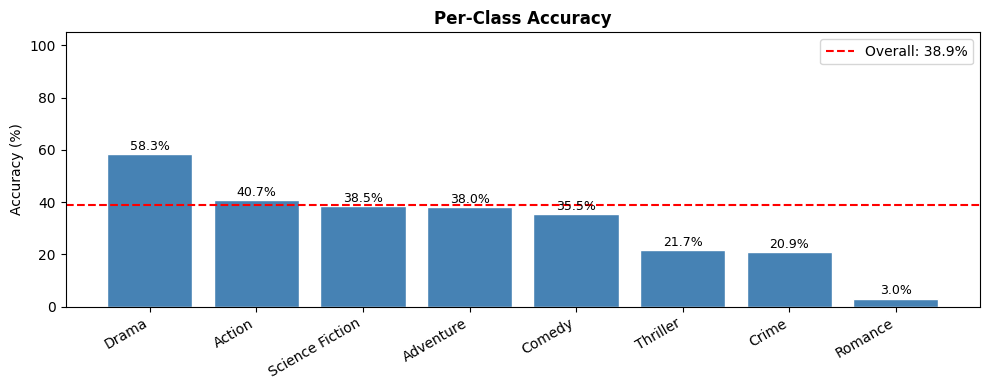

In [ ]:
# ── Per-class Accuracy Bar Chart ─────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df  = pd.DataFrame({'Genre': labels, 'Accuracy': per_class_acc})
per_class_df  = per_class_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(per_class_df['Genre'], per_class_df['Accuracy']*100,
               color='steelblue', edgecolor='white')
plt.axhline(test_acc*100, color='red', linestyle='--', label=f'Overall: {test_acc*100:.1f}%')
for bar, val in zip(bars, per_class_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Per-Class Accuracy', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(); plt.ylim(0, 105)
plt.tight_layout(); plt.show()

---
## 🔮 Step 8 — Predict Any Movie Description

> Write any movie overview below and the model will tell you its genre!

In [ ]:
# ── Prediction Function ───────────────────────────────────────────
@torch.no_grad()
def predict_genre(description: str, top_k: int = 3) -> None:
    """
    Predict the genre of a movie from its description.

    Parameters
    ----------
    description : str   — movie overview text (English)
    top_k       : int   — how many top predictions to show
    """
    model.eval()

    # Preprocess
    tokens   = clean_text(description)
    encoded  = encode(tokens)
    tensor   = torch.tensor([encoded], dtype=torch.long).to(DEVICE)

    # Forward pass
    logits   = model(tensor)                     # (1, C)
    probs    = torch.softmax(logits, dim=1)[0]   # (C,)

    # Top-K results
    top_vals, top_idxs = torch.topk(probs, k=min(top_k, NUM_CLASSES))

    # Pretty print
    print('=' * 55)
    print('  🎬  GENRE PREDICTION')
    print('=' * 55)
    print(f'  📝 Input: "{description[:70]}"' + ('...' if len(description)>70 else ''))
    print('-' * 55)
    for rank, (prob, idx) in enumerate(zip(top_vals, top_idxs), 1):
        genre = idx2genre[idx.item()]
        bar   = '█' * int(prob.item() * 30)
        marker = '  ← TOP PICK' if rank == 1 else ''
        print(f'  {rank}. {genre:<18} {prob.item()*100:5.1f}%  {bar}{marker}')
    print('=' * 55)

print('✅ predict_genre() is ready!')

✅ predict_genre() is ready!


In [ ]:
# ── Example 1: Action ─────────────────────────────────────────────
predict_genre(
    "A retired special forces operative is forced back into action "
    "when his daughter is kidnapped by a dangerous crime syndicate. "
    "Armed with deadly skills, he must fight through an entire city to bring her home."
)

  🎬  GENRE PREDICTION
  📝 Input: "A retired special forces operative is forced back into action when his"...
-------------------------------------------------------
  1. Action              82.7%  ████████████████████████  ← TOP PICK
  2. Crime                7.1%  ██
  3. Romance              4.3%  █


In [ ]:
# ── Example 2: Comedy ─────────────────────────────────────────────
predict_genre(
    "Two mismatched roommates accidentally swap lives when a bizarre "
    "series of mishaps leads them to each other's weddings, jobs, "
    "and families — with hilariously chaotic results."
)

  🎬  GENRE PREDICTION
  📝 Input: "Two mismatched roommates accidentally swap lives when a bizarre series"...
-------------------------------------------------------
  1. Comedy              82.4%  ████████████████████████  ← TOP PICK
  2. Crime                4.6%  █
  3. Romance              4.0%  █


In [ ]:
# ── Example 3: Science Fiction ────────────────────────────────────
predict_genre(
    "In a dystopian future, humanity has colonized distant galaxies. "
    "A lone astronaut discovers an alien signal that could either "
    "save the human race or trigger an interstellar war."
)

  🎬  GENRE PREDICTION
  📝 Input: "In a dystopian future, humanity has colonized distant galaxies. A lone"...
-------------------------------------------------------
  1. Science Fiction     98.0%  █████████████████████████████  ← TOP PICK
  2. Romance              0.8%  
  3. Crime                0.5%  


In [ ]:
# ── ✏️  YOUR TURN — Type any description here! ────────────────────
my_description = """A young woman moves to a small coastal town and falls in love 
with a mysterious fisherman who harbors a dark secret from his past."""

predict_genre(my_description)

  🎬  GENRE PREDICTION
  📝 Input: "A young woman moves to a small coastal town and falls in love 
with a "...
-------------------------------------------------------
  1. Drama               69.5%  ████████████████████  ← TOP PICK
  2. Romance              8.3%  ██
  3. Thriller             6.9%  ██


In [ ]:
# ── Save final model + metadata ───────────────────────────────────
import json

torch.save({
    'model_state':  model.state_dict(),
    'vocab_size':   VOCAB_SIZE,
    'embed_dim':    EMBED_DIM,
    'hidden_dim':   HIDDEN_DIM,
    'num_layers':   NUM_LAYERS,
    'num_classes':  NUM_CLASSES,
    'max_len':      MAX_LEN,
}, 'movie_genre_lstm_full.pt')

with open('vocab.json', 'w') as f:
    json.dump(word2idx, f)

with open('genre_map.json', 'w') as f:
    json.dump(idx2genre, f)

print('✅ Model, vocabulary, and genre map saved!')
print(f'\n🏆 Final Test Accuracy: {test_acc*100:.2f}%')

✅ Model, vocabulary, and genre map saved!

🏆 Final Test Accuracy: 38.93%
